In [ ]:
# This Block is referenced from Andrej Karpathy's micrograd project, which is a tiny autograd engine in Python. 
# It is used to demonstrate how backpropagation works in neural networks. The code defines a class called Value, 
# which represents a single scalar value and its gradient. The class includes methods for basic arithmetic operations, 
# as well as a method for computing the backward pass to calculate gradients. I have added the sigmoid function to the Value class.
# He modelled it after PyTorch's autograd system, which is why i find it important and easier to undertand.
# https://github.com/karpathy/micrograd/blob/master/micrograd/engine.py

import numpy as np
import random
import math

# seeding for reproducability cause its "The Answer to the Ultimate Question of Life, the Universe, and Everything"
np.random.seed(42)
random.seed(42)
# not working in ipynb

class Value:

    # a Value represents a single scalar value and its gradient
    def __init__(self, data, _children=()):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)

    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other))

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other))

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __pow__(self, other):
        out = Value(self.data**other, (self,))

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ))

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def log(self):
        x = self.data
        out = Value(math.log(x), (self, ))

        def _backward():
            self.grad += (1 / x) * out.grad
        out._backward = _backward

        return out
    
    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,))

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out
    
    def sigmoid(self):
        x = self.data
        out = Value(1 / (1 + math.exp(-x)), (self, ))

        def _backward():
            s = out.data
            self.grad += (s * (1 - s)) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __rsub__(self, other): # other - self
        return other + (-self)
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

In [58]:
# This Block is also referenced from Andrej Karpathy's micrograd project.
# Ive modified it to have the last layer implement a sigmoid activation function.
# https://github.com/karpathy/micrograd/blob/master/micrograd/nn.py

class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act.sigmoid()

    def parameters(self):
        return self.w + [self.b]
    
    def __repr__(self):
        return f"{'Relu' if self.nonlin else 'Sigmoid'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]
    
    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"


class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

In [ ]:
# This Block is also referenced from Andrej Karpathy's micrograd project.
# Its been referenced from a demo file he provided which ive modified into binary classifier neural network trainer class.
# https://github.com/karpathy/micrograd/blob/master/demo.ipynb 

from matplotlib.pylab import inf

class LogisticRegressionTrainer:
    
    def __init__(self, X, y, hidden_layers=[1]):
        self.X = X
        self.y = y
        self.hidden_layers = hidden_layers
        self.model = MLP(len(X[0]), hidden_layers)
        self.X_train, self.y_train, self.X_val, self.y_val, self.X_test, self.y_test = self.split_train_val_test()

    def loss(self, batch_size=None):
        
        if batch_size is None:
            Xb, yb = self.X_train, self.y_train
        else:
            # creates a random shuffle of indices and slices based on batch size
            ri = np.random.permutation(len(self.X_train))[:batch_size]
            Xb = self.X_train[ri]
            yb = self.y_train[ri]

        inputs = [list(map(Value, xrow)) for xrow in Xb]
        # forward pass
        scores = list(map(self.model, inputs))

        # binary cross-entropy loss for logistic regression
        losses = [
            -(yi * yhi.log() + (1 - yi) * (1 - yhi).log())
            for yi, yhi in zip(yb, scores)
        ]

        data_loss = sum(losses) / len(losses)

        accuracy = [
            (scorei.data >= 0.5) == yi
            for yi, scorei in zip(yb, scores)
        ]

        return data_loss, sum(accuracy) / len(accuracy)

    def train(self, epochs=100, learning_rate=0.05, N=10, threshold=1e-2, batch_size=None):
        iteration = 0
        J_running = 0.0
        J_running_prev = inf
        stopping = False

        while not stopping:

            total_loss, acc = self.loss(batch_size)

            iteration += 1
            J_running += total_loss.data

            # zeroing gradients before backward pass
            self.model.zero_grad()
            # backward pass to compute gradients
            total_loss.backward()

            # updating weights and biases
            for p in self.model.parameters():
                p.data -= learning_rate * p.grad

            print(f"step {iteration} loss {total_loss.data:.4f}, accuracy {acc*100:.2f}%")

            if iteration >= epochs:
                stopping = True
                print("Reached maximum iterations.")
                break

            # for every N runs
            if iteration % N == 0:
                # compare average running loss to previous
                avg_J_running = J_running / N
                if abs(J_running_prev - avg_J_running) < threshold:
                    stopping = True
                    print(f"Converged after {iteration} iterations.")
                    break
                # reset running loss for next batch
                J_running_prev = avg_J_running
                J_running = 0.0


    def predict(self, X):
        inputs = [list(map(Value, xrow)) for xrow in X]
        scores = list(map(self.model, inputs))
        return np.array([1 if s.data >= 0.5 else 0 for s in scores])
    
    def split_train_val_test(self, train_ratio=0.7, val_ratio=0.15):
        n = len(self.X)
        # randomized indices
        indices = np.random.permutation(n)

        # calculating indices to split from for eg 100 samples give 70 and 85
        train_end = int(train_ratio * n)
        val_end = int((train_ratio + val_ratio) * n)

        train_idx = indices[:train_end]
        val_idx = indices[train_end:val_end]
        test_idx = indices[val_end:]

        return (
            self.X[train_idx], self.y[train_idx],
            self.X[val_idx], self.y[val_idx],
            self.X[test_idx], self.y[test_idx]
        )
    
    def evaluate(self):
        inputs = [list(map(Value, xrow)) for xrow in self.X_val]
        scores = list(map(self.model, inputs))
        yhat = [1 if s.data >= 0.5 else 0 for s in scores]
        acc = sum([yh == y_true for yh, y_true in zip(yhat, self.y_val)]) / len(self.y_val)

        losses = [
            -(yi * math.log(yhi.data) + (1 - yi) * math.log((1 - yhi.data)))
            for yi, yhi in zip(self.y_val, scores)
        ]
        loss = sum(losses) / len(losses)
        return f"loss {loss:.4f}, accuracy {acc*100:.2f}%"
    
    def reset(self):
        self.model = MLP(len(self.X[0]),self.hidden_layers)
    


In [65]:
# TASK 1: Implement Logistic Regression
# This will use the above 3 implemented classes to test a logistic regressor with one output neuron and no Hidden Layers.
# This code references the train function of the LogisticRegressionTrainer class, which is modified based on the pseudocode provided in the lecture notes.
# It supports multiple features per training sample and a different number of training samples.

# randomly generated dataset with 2 features and binary labels
X = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [1, 3],
    [2, 4],
    [3, 5],
    [4, 6],
    [5, 6],
    [6, 7],
    [0, 1],
    [7, 8]
])

y = np.array([
    0, 0, 1, 1,
    0, 0, 1, 1,
    1, 1,
    0, 1
])

testModel = LogisticRegressionTrainer(X, y)
testModel.train(learning_rate=.4)
testModel.evaluate()

step 1 loss 1.7585, accuracy 37.50%
step 2 loss 1.8405, accuracy 50.00%
step 3 loss 0.9399, accuracy 50.00%
step 4 loss 0.6501, accuracy 75.00%
step 5 loss 0.8108, accuracy 50.00%
step 6 loss 0.5694, accuracy 100.00%
step 7 loss 0.7022, accuracy 62.50%
step 8 loss 0.4984, accuracy 100.00%
step 9 loss 0.5934, accuracy 62.50%
step 10 loss 0.4435, accuracy 100.00%
step 11 loss 0.5113, accuracy 62.50%
step 12 loss 0.3930, accuracy 100.00%
step 13 loss 0.4302, accuracy 75.00%
step 14 loss 0.3523, accuracy 100.00%
step 15 loss 0.3689, accuracy 75.00%
step 16 loss 0.3170, accuracy 100.00%
step 17 loss 0.3190, accuracy 75.00%
step 18 loss 0.2874, accuracy 100.00%
step 19 loss 0.2818, accuracy 87.50%
step 20 loss 0.2632, accuracy 100.00%
step 21 loss 0.2553, accuracy 100.00%
step 22 loss 0.2441, accuracy 100.00%
step 23 loss 0.2366, accuracy 100.00%
step 24 loss 0.2291, accuracy 100.00%
step 25 loss 0.2228, accuracy 100.00%
step 26 loss 0.2170, accuracy 100.00%
step 27 loss 0.2116, accuracy 100

'loss 0.3192, accuracy 100.00%'

The dimensions of the dataset are: (600, 3)


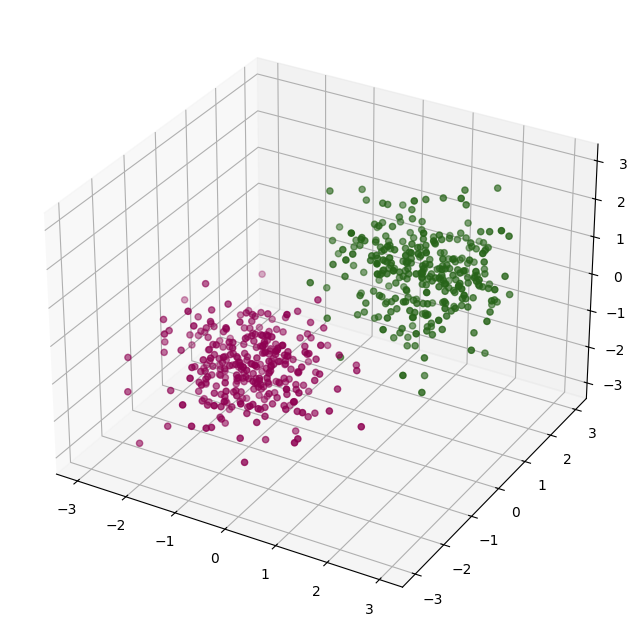

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
# Loading in the Dataset with 3 features and 1 class
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv("blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

print(f"The dimensions of the dataset are: {np.shape(X1)}")

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

The dimensions of Dataset 2 are: (500, 2)


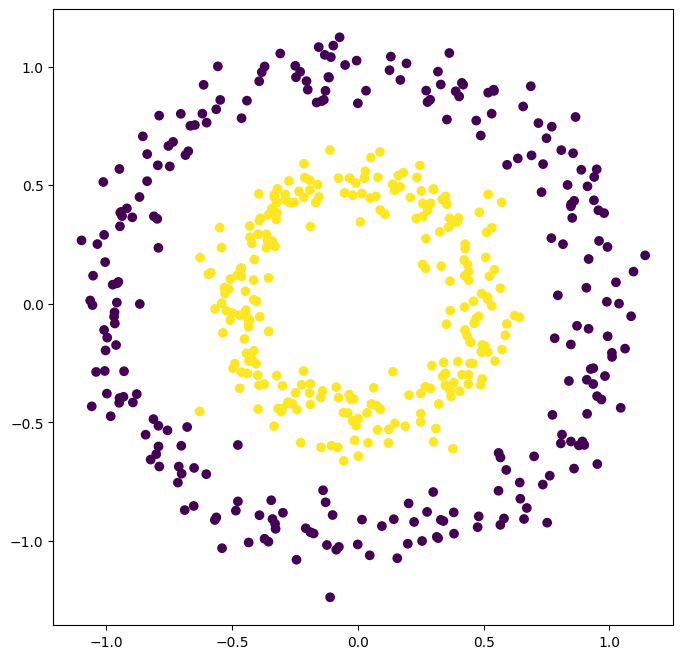

In [67]:
# Loading in the Dataset with 2 features and 1 class
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv("circles500.csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8)) 

ax.scatter(X2[:,0], X2[:,1], c=y2) 

plt.show()
plt.close(fig)

In [ ]:
# TASK 2: Testing on Datasets

D3valmodel = LogisticRegressionTrainer(X1, y1)
D2valmodel = LogisticRegressionTrainer(X2, y2)

